# Knapsack Problem

**Knapsack Problem**

Given n items where each item has some weight and profit associated with it and also given a bag with capacity W, [i.e., the bag can hold at most W weight in it]. The task is to put the items into the bag such that the sum of profits associated with them is the maximum possible. 

Note: The constraint here is we can either put an item completely into the bag or cannot put it at all [It is not possible to put a part of an item into the bag].

- Input:  W = 4, profit[] = [1, 2, 3], weight[] = [4, 5, 1]
- Output: 3
- Explanation: There are two items which have weight less than or equal to 4. If we select the item with weight 4, the possible profit is 1. And if we select the item with weight 1, the possible profit is 3. So the maximum possible profit is 3. Note that we cannot put both the items with weight 4 and 1 together as the capacity of the bag is 4.

Ref: https://www.geeksforgeeks.org/0-1-knapsack-problem-dp-10/

### naive approach

Using Recursion O(2^n) Time and O(n) Space

Follow the below steps to solve the problem:

The maximum value obtained from 'n' items is the max of the following two values. 

- Case 1 (pick the nth item): Value of the nth item + maximum value obtained by remaining (n-1) items and remaining weight i.e. (W-weight of the nth item).
- Case 2 (don't pick the nth item): Maximum value obtained by (n-1) items and W weight.
- If the weight of the 'nth' item is greater than 'W', then the nth item cannot be included and Case 2 is the only possibility.

(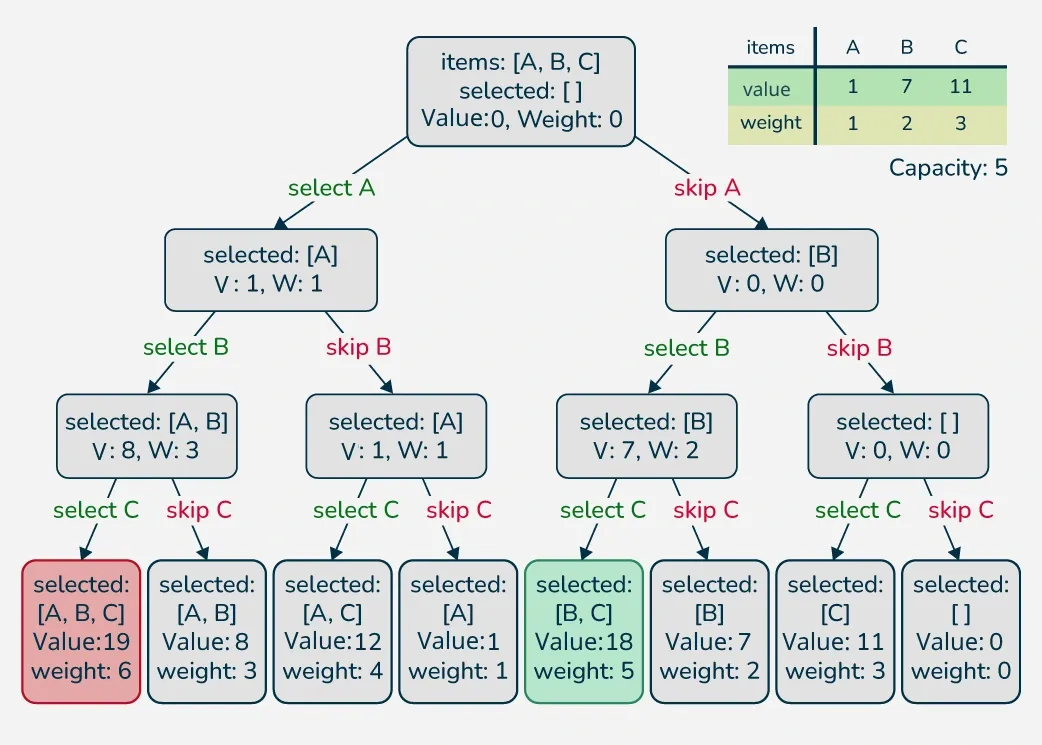)

In [1]:
# Returns the maximum value that
# can be put in a knapsack of capacity W
def knapsackRec(W: int, val: list, wt: list, n: int):

    # Base Case
    if n == 0 or W == 0:
        return 0

    pick = 0

    # Pick nth item if it does not exceed the capacity of knapsack
    if wt[n - 1] <= W:
        pick = val[n - 1] + knapsackRec(W - wt[n - 1], val, wt, n - 1)

    # Don't pick the nth item
    notPick = knapsackRec(W, val, wt, n - 1)

    return max(pick, notPick)


def knapsack(W: int, val: list, wt: list):
    n = len(val)
    return knapsackRec(W, val, wt, n)


if __name__ == "__main__":
    val = [1, 2, 3]
    wt = [4, 5, 1]
    W = 4

    print(knapsack(W, val, wt))

3


### Using Top-Down DP (Memoization)- O(n x W) Time and Space

Note: The above function using recursion computes the same subproblems again and again. See the following recursion tree, K(1, 1) is being evaluated twice.

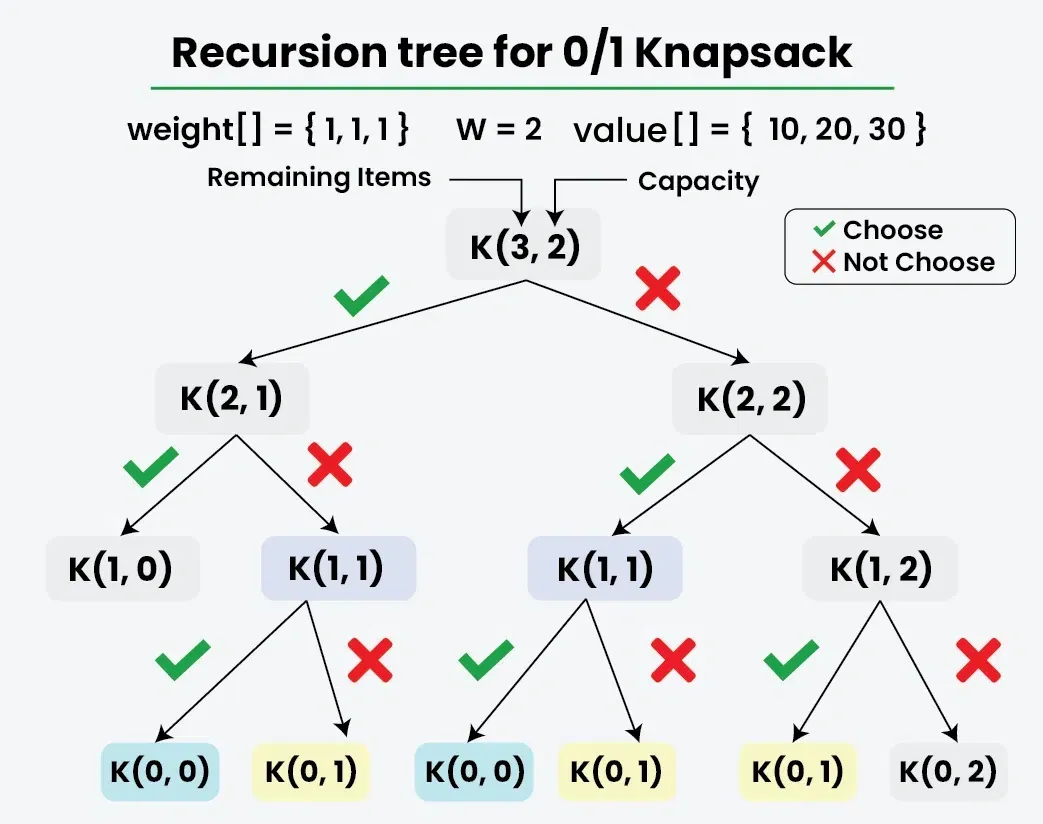

In [2]:
# Returns the maximum value that
# can be put in a knapsack of capacity W
def knapsackRec(W: int, val: list, wt: list, n: int, memo: list):

    # Base Case
    if n == 0 or W == 0:
        return 0

    # Check if we have previously calculated the same subproblem
    if memo[n][W] != -1:
        return memo[n][W]

    pick = 0

    # Pick nth item if it does not exceed the capacity of knapsack
    if wt[n - 1] <= W:
        pick = val[n - 1] + knapsackRec(W - wt[n - 1], val, wt, n - 1, memo)

    # Don't pick the nth item
    notPick = knapsackRec(W, val, wt, n - 1, memo)

    # Store the result in memo[n][W] and return it
    memo[n][W] = max(pick, notPick)
    return memo[n][W]


def knapsack(W: int, val: list, wt: list):
    n = len(val)

    # Memoization table to store the results
    memo = [[-1] * (W + 1) for _ in range(n + 1)]

    return knapsackRec(W, val, wt, n, memo)


if __name__ == "__main__":
    val = [1, 2, 3]
    wt = [4, 5, 1]
    W = 4

    print(knapsack(W, val, wt))

3


### Using Bottom-Up DP (Tabulation) - O(n x W) Time and Space

There are two parameters that change in the recursive solution and these parameters go from 0 to n and 0 to W. So we create a 2D dp[][] array of size (n+1) x (W+1), such that dp[i][j] stores the maximum value we can get using i items such that the knapsack capacity is j.

- We first fill the known entries when m is 0 or n is 0.
- Then we fill the remaining entries using the recursive formula.

For each item i and knapsack capacity j, we decide whether to pick the item or not.

- If we don't pick the item: dp[i][j] remains same as the previous item, that is dp[i - 1][j].
- If we pick the item: dp[i][j] is updated to val[i] + dp[i - 1][j - wt[i]].

In [3]:
def knapsack(W, val, wt):
    n = len(wt)
    dp = [[0 for _ in range(W + 1)] for _ in range(n + 1)]

    # Build table dp[][] in bottom-up manner
    for i in range(n + 1):
        for j in range(W + 1):

            # If there is no item or the knapsack's capacity is 0
            if i == 0 or j == 0:
                dp[i][j] = 0
            else:
                pick = 0

                # Pick ith item if it does not exceed the capacity of knapsack
                if wt[i - 1] <= j:
                    pick = val[i - 1] + dp[i - 1][j - wt[i - 1]]

                # Don't pick the ith item
                notPick = dp[i - 1][j]

                dp[i][j] = max(pick, notPick)

    return dp[n][W]


if __name__ == "__main__":
    val = [1, 2, 3]
    wt = [4, 5, 1]
    W = 4

    print(knapsack(W, val, wt))

3


### Using Bottom-Up DP (Space-Optimized) - O(n x W) Time and O(W) Space

For calculating the current row of the dp[] array we require only previous row, but if we start traversing the rows from right to left then it can be done with a single row only

In [4]:
# Function to find the maximum profit
def knapsack(W, val, wt):

    # Initializing dp list
    dp = [0] * (W + 1)

    # Taking first i elements
    for i in range(1, len(wt) + 1):

        # Starting from back, so that we also have data of
        # previous computation of i-1 items
        for j in range(W, wt[i - 1] - 1, -1):
            dp[j] = max(dp[j], dp[j - wt[i - 1]] + val[i - 1])

    return dp[W]


if __name__ == "__main__":
    val = [1, 2, 3]
    wt = [4, 5, 1]
    W = 4

    print(knapsack(W, val, wt))

3
